In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")

In [ ]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before:", y_train.value_counts())
print("After :", pd.Series(y_train_smote).value_counts())


Before: Diabetes_binary
0.0    174667
1.0     28277
Name: count, dtype: int64
After : Diabetes_binary
0.0    174667
1.0    174667
Name: count, dtype: int64


In [ ]:
et = ExtraTreesClassifier(random_state=42)

In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "criterion": ["gini", "entropy"]
}

In [ ]:
grid = GridSearchCV(
    et,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [ ]:
grid.n_jobs = 2
grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(grid.best_params_)

best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

best_model = grid.best_estimator_

Best Parameters:
{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Parameters:
{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [ ]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Accuracy: 0.8563938820561338

ROC AUC: 0.7960097663348538

Classification Report
              precision    recall  f1-score   support

         0.0       0.88      0.96      0.92     43667
         1.0       0.46      0.20      0.28      7069

    accuracy                           0.86     50736
   macro avg       0.67      0.58      0.60     50736
weighted avg       0.82      0.86      0.83     50736



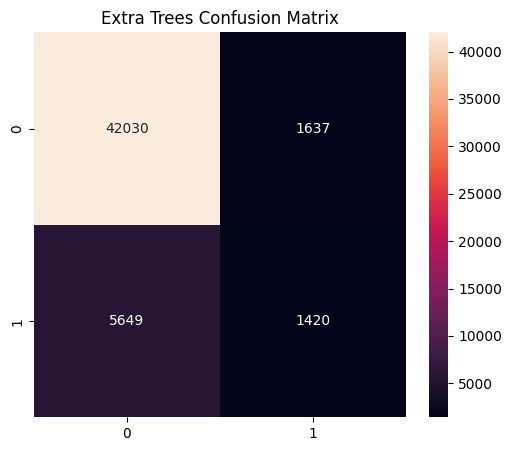

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Extra Trees Confusion Matrix")
plt.show()

### 1. Feature Importance
Let's start with the global importance scores provided by the Extra Trees algorithm.

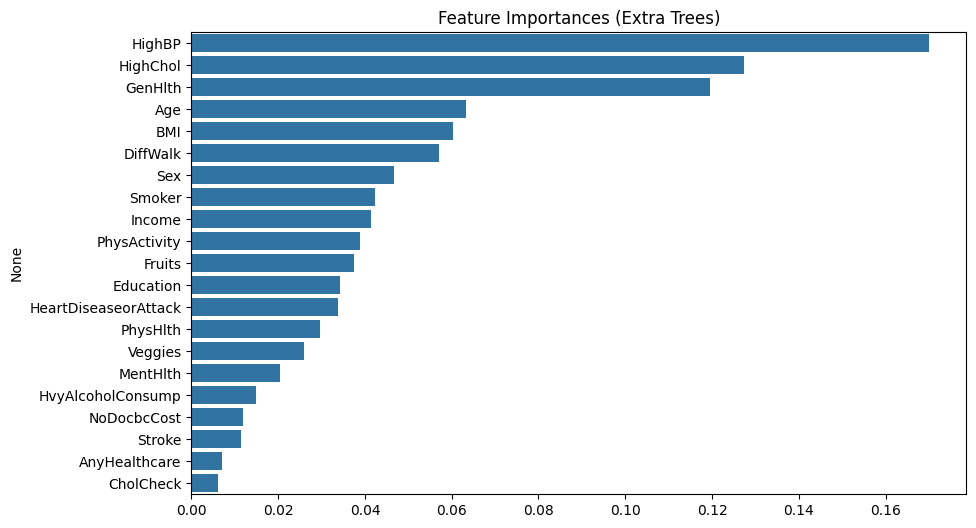

In [ ]:
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Extra Trees)")
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.show()

### 2. SHAP (SHapley Additive exPlanations)
SHAP values provide a unified measure of feature importance by calculating the contribution of each feature to the prediction.

In [ ]:
!pip install shap
import shap

# We use a subset for faster calculation
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test.iloc[:100])



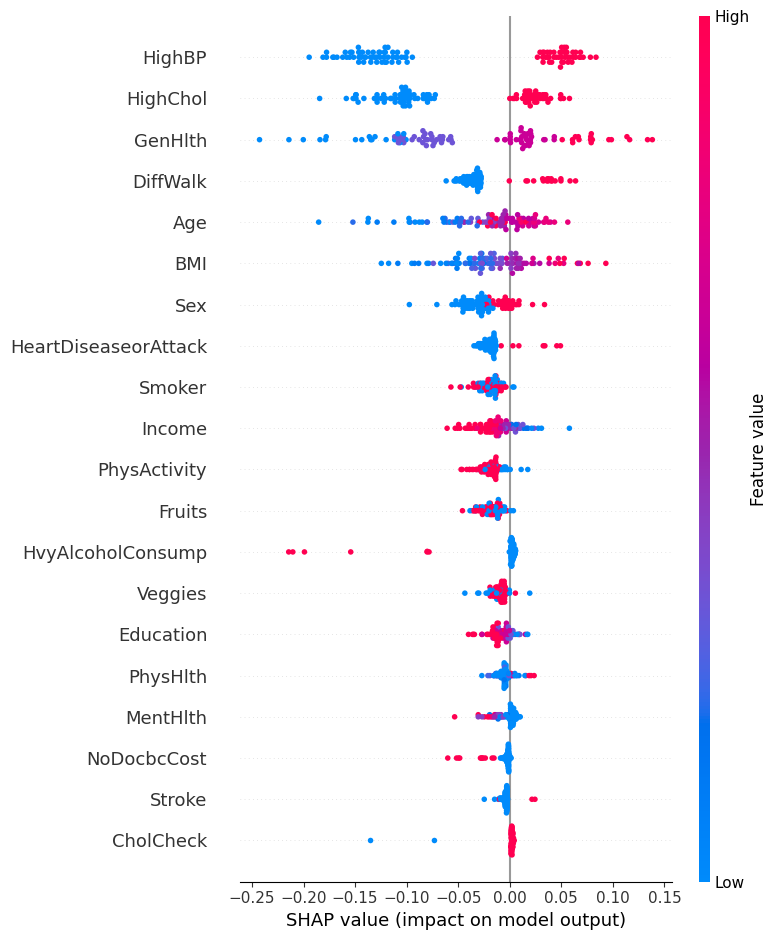

In [ ]:
shap.summary_plot(shap_values[:, :, 1], X_test.iloc[:100])

### 3. LIME
LIME explains individual predictions by approximating the model locally with an interpretable one.

In [ ]:
!pip install lime
from lime import lime_tabular
from IPython.display import HTML

predict_fn = lambda x: best_model.predict_proba(x)

explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['No Diabetes', 'Diabetes'],
    mode='classification'
)

# Explain a single instance
exp = explainer_lime.explain_instance(X_test.iloc[0], predict_fn)
HTML(exp.as_html())

/home/seif_khashaba/miniconda3/envs/tf_env/lib/python3.12/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/seif_khashaba/miniconda3/envs/tf_env/lib/python3.12/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/seif_khashaba/miniconda3/envs/tf_env/lib/python3.12/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be 

### 4. Partial Dependence Plots (PDP)
PDPs show the relationship between a feature and the predicted probability.

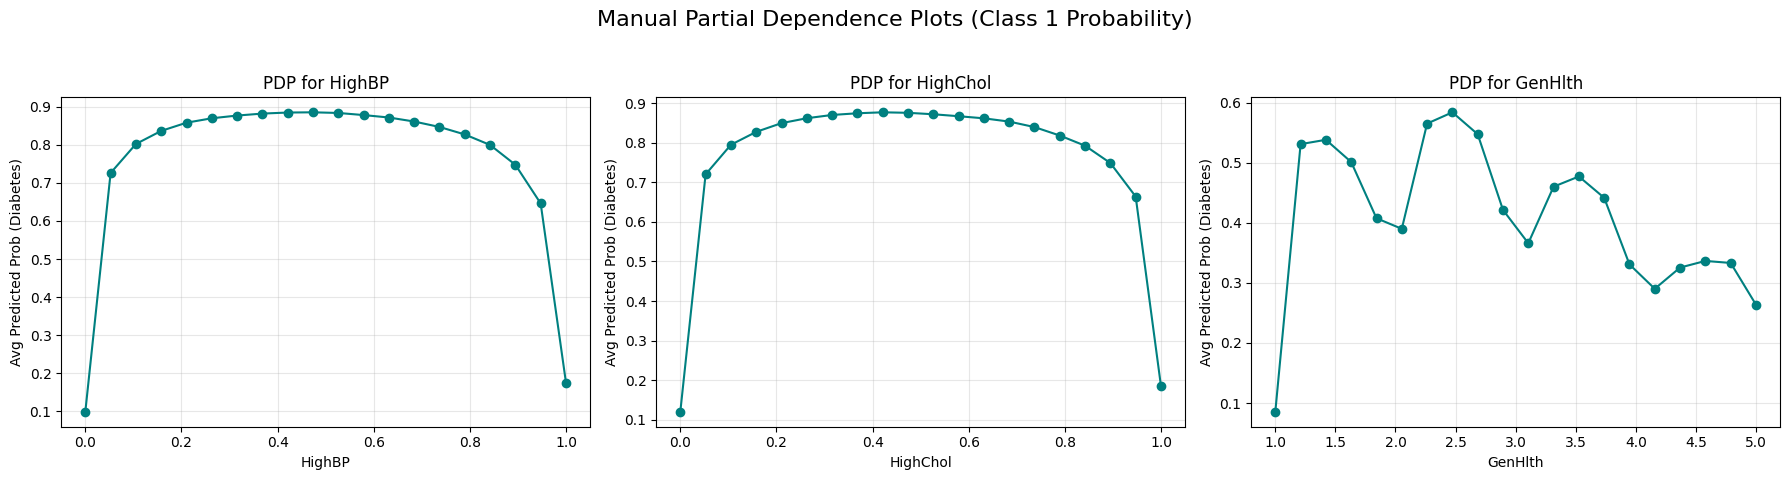

In [ ]:
import matplotlib.pyplot as plt

# Manual PDP calculation to bypass sklearn internal reshape errors
def manual_pdp(model, X_sample, feature_name, grid_resolution=20):
    grid = np.linspace(X_sample[feature_name].min(), X_sample[feature_name].max(), grid_resolution)
    pdp_values = []
    X_temp = X_sample.copy()

    for val in grid:
        X_temp[feature_name] = val
        # Get average probability of the positive class (Diabetes)
        prob = model.predict_proba(X_temp)[:, 1].mean()
        pdp_values.append(prob)
    return grid, pdp_values

features_to_plot = X.columns[indices[:3]].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calculate and plot for each feature
for i, col in enumerate(features_to_plot):
    grid, values = manual_pdp(best_model, X_test.iloc[:500], col)
    axes[i].plot(grid, values, marker='o', color='teal')
    axes[i].set_title(f"PDP for {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Avg Predicted Prob (Diabetes)")
    axes[i].grid(alpha=0.3)

plt.suptitle("Manual Partial Dependence Plots (Class 1 Probability)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 5. Permutation Importance
This technique measures importance by observing how the score changes when one feature is randomly shuffled.

/tmp/ipykernel_2196/2883222506.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])


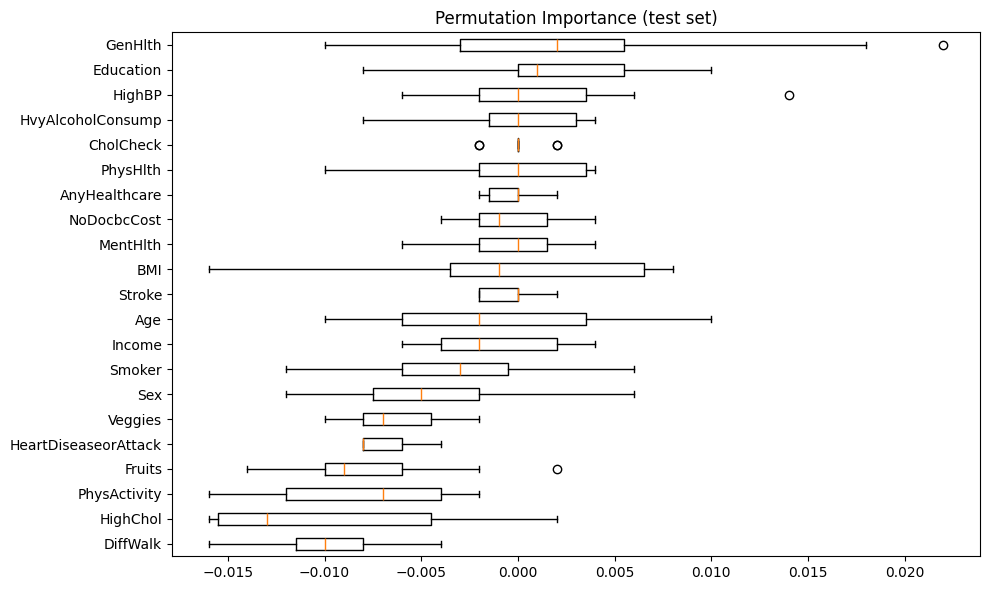

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(best_model, X_test.iloc[:500], y_test.iloc[:500], n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])
plt.title("Permutation Importance (test set)")
plt.tight_layout()
plt.show()